Гипотеза 3: Создание новых признаков.

Цель: создание новых признаков, отражающих финансовую нагрузку заемщика через отношения ключевых финансовых показателей.
credit_to_income: Отношение суммы кредита к годовому доходу (amt_credit / amt_income_total)
annuity_to_income: Отношение аннуитетного платежа к годовому доходу (amt_annuity / amt_income_total)

In [1]:
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

In [2]:
df_train = pd.read_csv('train_final_processed.csv')
df_test = pd.read_csv('test_final_processed.csv')
print(f"Размер тренировочных данных: {df_train.shape}")
print(f"Размер тестовых данных: {df_test.shape}")

Размер тренировочных данных: (307511, 571)
Размер тестовых данных: (48744, 570)


In [3]:
X_train_full = df_train.drop(['sk_id_curr', 'target'], axis=1)
y_train_full = df_train['target']

In [4]:
if y_train_full.dtype == 'object' or len(y_train_full.unique()) > 2:
    y_train_full = y_train_full.map({'0': 0, '1': 1}).fillna(0).astype(int)

In [5]:
common_cols = X_train_full.columns.intersection(df_test.drop(['sk_id_curr'], axis=1).columns)
if len(common_cols) < 10:
    print("Предупреждение")
X_train_full = X_train_full[common_cols]
df_test_processed = df_test[common_cols]

In [7]:
cat_cols = [col for col in common_cols if X_train_full[col].dtype == 'object']
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train_full[col] = X_train_full[col].astype(str).fillna('missing')
    df_test_processed[col] = df_test_processed[col].astype(str).fillna('missing')
    
    all_values = pd.concat([X_train_full[col], df_test_processed[col]], axis=0).unique()
    le.fit(all_values) 
    
    X_train_full[col] = le.transform(X_train_full[col])
    df_test_processed[col] = le.transform(df_test_processed[col])

In [8]:
for col in X_train_full.columns:
    X_train_full[col] = pd.to_numeric(X_train_full[col], errors='coerce')
    df_test_processed[col] = pd.to_numeric(df_test_processed[col], errors='coerce')

for col in X_train_full.columns:
    if X_train_full[col].dtype in ['float64', 'int64']:
        X_train_full[col].fillna(X_train_full[col].median(), inplace=True)
        df_test_processed[col].fillna(X_train_full[col].median(), inplace=True)

C:\Users\klmv0\AppData\Local\Temp\ipykernel_6328\1661528756.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_processed[col] = pd.to_numeric(df_test_processed[col], errors='coerce')
C:\Users\klmv0\AppData\Local\Temp\ipykernel_6328\1661528756.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_processed[col].fillna(X_train_full[col].median(), inplace=True)
C:\Users\klmv0\AppData\Local\Temp\ipykernel_6328\1661528756.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentatio

In [14]:
print("Шаг 4: Добавление финансовых отношений...")
# Проверяем наличие нужных столбцов с маленькими буквами
required_cols = ['amt_credit', 'amt_income_total', 'amt_annuity']
missing_cols = [col for col in required_cols if col not in common_cols]
if missing_cols:
    print(f"Предупреждение: Отсутствуют столбцы: {missing_cols}. Используем доступные.")
# Создаём новые фичи
if 'amt_income_total' in common_cols and X_train_full['amt_income_total'].notna().any():  # Проверяем наличие ненулевых значений
    X_train_full['credit_to_income'] = X_train_full['amt_credit'] / X_train_full['amt_income_total']
    df_test_processed['credit_to_income'] = df_test_processed['amt_credit'] / df_test_processed['amt_income_total']
if 'amt_annuity' in common_cols and 'amt_income_total' in common_cols and X_train_full['amt_income_total'].notna().any():
    X_train_full['annuity_to_income'] = X_train_full['amt_annuity'] / X_train_full['amt_income_total']
    df_test_processed['annuity_to_income'] = df_test_processed['amt_annuity'] / df_test_processed['amt_income_total']
# Обработка деления на ноль или пропусков
X = X_train_full.fillna(0)
df_test_processed = df_test_processed.fillna(0)
print(f"Добавлены новые фичи: {'credit_to_income' if 'credit_to_income' in X else ''}, {'annuity_to_income' if 'annuity_to_income' in X else ''}")

Шаг 4: Добавление финансовых отношений...
Добавлены новые фичи: credit_to_income, annuity_to_income


In [15]:
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

In [16]:
cat_model_optimal = CatBoostClassifier(
    iterations=1000,     
    learning_rate=0.03,       
    depth=7,          
    auto_class_weights='SqrtBalanced',
    random_state=42,
    l2_leaf_reg=2,  
    eval_metric='AUC',
    loss_function='Logloss',
    verbose=100)

cat_model_optimal.fit(X_train, y_train, eval_set=(X_val, y_val), cat_features=cat_cols)

0:	test: 0.6960228	best: 0.6960228 (0)	total: 674ms	remaining: 11m 13s
100:	test: 0.7636186	best: 0.7636186 (100)	total: 36.8s	remaining: 5m 27s
200:	test: 0.7736837	best: 0.7736837 (200)	total: 1m 14s	remaining: 4m 57s
300:	test: 0.7776958	best: 0.7776958 (300)	total: 1m 57s	remaining: 4m 32s
400:	test: 0.7803174	best: 0.7803174 (400)	total: 2m 39s	remaining: 3m 58s
500:	test: 0.7830880	best: 0.7830996 (499)	total: 3m 29s	remaining: 3m 28s
600:	test: 0.7846925	best: 0.7846925 (600)	total: 4m 13s	remaining: 2m 48s
700:	test: 0.7856118	best: 0.7856283 (698)	total: 4m 49s	remaining: 2m 3s
800:	test: 0.7861635	best: 0.7861635 (800)	total: 5m 31s	remaining: 1m 22s
900:	test: 0.7866858	best: 0.7867169 (899)	total: 6m 11s	remaining: 40.8s
999:	test: 0.7870228	best: 0.7870608 (991)	total: 6m 45s	remaining: 0us

bestTest = 0.7870607892
bestIteration = 991

Shrink model to first 992 iterations.


In [17]:
y_val_pred_proba = cat_model_optimal.predict_proba(X_val)[:, 1]
val_metrics = {
    'ROC-AUC': roc_auc_score(y_val, y_val_pred_proba),
    'Accuracy': accuracy_score(y_val, y_val_pred_proba > 0.5),
    'Precision': precision_score(y_val, y_val_pred_proba > 0.5),
    'Recall': recall_score(y_val, y_val_pred_proba > 0.5),
    'F1-Score': f1_score(y_val, y_val_pred_proba > 0.5)
}
for metric, value in val_metrics.items():
    print(f'Validation {metric}: {value:.4f}')

Validation ROC-AUC: 0.7871
Validation Accuracy: 0.9045
Validation Precision: 0.3711
Validation Recall: 0.2638
Validation F1-Score: 0.3084


In [19]:
test_pred_proba = cat_model_optimal.predict_proba(df_test_processed)[:, 1]
submission = pd.DataFrame({
    'sk_id_curr': df_test['sk_id_curr'],
    'target': test_pred_proba
})
submission.to_csv('submission_baseline_3.csv', index=False)

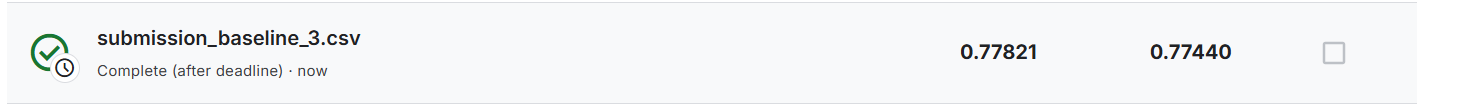

Видим, что поднялся public_score(+0.00104). Попробуем еще поработать над данной гипезой, чтобы повыси private_public